---
title: "Melbourne Property Market - Exploratory Data Analysis "
author: "Hoang Son Lai"
date: "05/12/2026"
format: 
 html:
  toc: true
  css: styles.css
  embed-resources: true
  code-fold: true
---

## Introduction

This report performs end-to-end EDA on Melbourne property listings to prepare a clean dataset for downstream price prediction.

Data snapshot: this report uses data updated on 2 May 2026.

The dataset combines two distinct groups of records:

- Sold: completed transactions with a transaction `Date` and (usually) a `Numeric_Price`. These are the future training labels.

- For Sale: active listings with no `Date` and no reliable price. These are the records I will price-predict in the ML notebook.

Because the two groups play fundamentally different roles in the pipeline, I split them early and analyze each on its own, and also side-by-side, throughout the report.

Workflow: setup, data quality, outlier handling, univariate, bivariate, time series, geospatial, Sold-vs-ForSale drift, summary, save cleaned parquet.

## 1. Data Loading & Initial Inspection

I read the CSV, normalize a possible BOM in the first column name, then inspect the schema. The very first thing I look at is the `Status` distribution - this confirms the two-group structure that motivates the entire analysis.

In [31]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

# To convert to html, quarto render report/eda_report.ipynb

In [32]:
# Load Data
df = pd.read_csv('report_data/melbourne_price_data_enriched.csv')

In [33]:
# Strip BOM if present (CSVs saved from Excel often carry one on the first column)
df.columns = [c.lstrip("\ufeff") for c in df.columns]

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB\n")

print("Status distribution:")
print(df["Status"].value_counts())
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))

Shape: (163466, 27)
Memory: 132.0 MB

Status distribution:
Status
Sold        124959
For Sale     38507
Name: count, dtype: int64

Columns (27):
['Property_ID', 'Status', 'Full_Address', 'Suburb', 'Postcode', 'Property_Type', 'Date', 'Beds', 'Baths', 'Car_Spaces', 'LandSize_sqm', 'Propertycount', 'Raw_Price', 'Numeric_Price', 'Latitude', 'Longitude', 'Distance_to_CBD_km', 'URL', 'Last_Updated', 'abs_median_income_weekly', 'abs_median_age', 'abs_population', 'crime_offence_count', 'crime_suburb_ref', 'crime_rate_per_100k', 'dist_nearest_train_km', 'Enriched_Date']


I parse `Date` into a real datetime column and extract `Year` and `Month` - these will be central features in the ML notebook because they let the model learn price inflation. I then split into `df_sold` and `df_forsale`. I also confirm my assumption that For Sale rows have no Date (it's the defining structural difference between the two groups).

In [34]:
# Format in the file is "10 Dec 2012"
df["Date_parsed"] = pd.to_datetime(df["Date"], format="%d %b %Y", errors="coerce")
df["Year"]  = df["Date_parsed"].dt.year
df["Month"] = df["Date_parsed"].dt.month

df_sold    = df[df["Status"] == "Sold"].copy()
df_forsale = df[df["Status"] == "For Sale"].copy()

print("Sold - Date coverage:")
print(f"  min  : {df_sold['Date_parsed'].min()}")
print(f"  max  : {df_sold['Date_parsed'].max()}")
print(f"  NaN  : {df_sold['Date_parsed'].isna().sum():,}  "
      f"({df_sold['Date_parsed'].isna().mean()*100:.1f}%)")

print("\nFor Sale - Date coverage (expected: all NaN):")
print(f"  NaN  : {df_forsale['Date_parsed'].isna().sum():,}  "
      f"({df_forsale['Date_parsed'].isna().mean()*100:.1f}%)")

print("\nYear range in Sold:")
print(df_sold["Year"].describe().round(0))

Sold - Date coverage:
  min  : 2001-10-13 00:00:00
  max  : 2026-05-02 00:00:00
  NaN  : 109  (0.1%)

For Sale - Date coverage (expected: all NaN):
  NaN  : 38,507  (100.0%)

Year range in Sold:
count    124850.0
mean       2024.0
std           3.0
min        2001.0
25%        2023.0
50%        2025.0
75%        2025.0
max        2026.0
Name: Year, dtype: float64


**Observations from the output:**

- For Sale Date is 100% NaN, as expected. This confirms the structural assumption that For Sale listings carry no transaction date. This is why the ML notebook will inject the current Year and Month at inference time to obtain "today-priced" predictions.

- Sold Date spans 13 Oct 2001 to 2 May 2026, a window of roughly 24.5 years.

- Only 109 Sold rows (0.1%) have a missing Date. These will be excluded from time-aware training because Year and Month features cannot be derived for them.

- Year distribution is heavily concentrated in recent years. The 25th percentile is 2023, median is 2025, and 75th percentile is 2025. At least half of Sold transactions occurred in 2025 alone. The bulk of the data sits in 2023–2026 and the early-2000s tail is thin.

**Implications for the ML pipeline:**

1. Time-based 70/15/15 split will allocate roughly:

   - Train: everything up to a cutoff somewhere in early or mid 2025.
   - Validation: a few months in 2025.
   - Test: late 2025 to May 2026.
   
   The exact cutoff dates will be computed in the ML notebook from sorted `Date_parsed`.

2. Recency bias is a feature, not a bug. The model will be used to price For Sale listings at the current market level (May 2026), so having most training data from 2023–2026 is advantageous. The model will be heavily informed by recent price dynamics.

3. The early-2000s tail (2001–2015) is sparse and will mostly land in the train fold. Median price by year (Section 6) will likely be noisy in those early years. I will filter low-volume years in the time-series visualization to avoid misleading trend lines.

4. No data leakage risk from the 2 May 2026 snapshot date. The latest Sold date equals the snapshot date, confirming the data was scraped fresh on that day. For Sale listings represent the supply standing on that exact date.

## 2. Data Quality Check

Before any descriptive analysis or outlier handling, I systematically check three families of data quality issues. The order matters: I check existence (missingness, duplicates) before validity (price availability, type sanity), because computing IQRs or histograms on a column that is heavily NaN gives misleading results.

The three checks are missingness per group, duplicate Property_IDs, and Property_Type sanity including long-tail categories. I also inspect Raw_Price values for rows where Numeric_Price is NaN, to confirm whether any of them can be recovered. At the end of this section I remove the rows that these checks identify as unrecoverable, so that everything downstream operates on a cleaner dataset.

In [ ]:
# Build a per-column NaN report, sorted by missing count, with both absolute and percentage figures.
def missing_report(d, name):
    miss = d.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)   # only show columns that have at least one NaN
    pct  = (miss / len(d) * 100).round(2)
    out  = pd.DataFrame({"missing": miss, "pct": pct})
    out.index.name = f"{name} (n={len(d):,})"
    return out

print("=== Missingness - Sold ===")
print(missing_report(df_sold, "Sold"))

print("\n=== Missingness - For Sale ===")
print(missing_report(df_forsale, "For Sale"))

=== Missingness - Sold ===
                     missing   pct
Sold (n=124,959)                  
Numeric_Price          10334  8.27
Date                     109  0.09
Year                     109  0.09
Date_parsed              109  0.09
Month                    109  0.09
crime_offence_count       19  0.02
crime_suburb_ref          19  0.02
crime_rate_per_100k       19  0.02

=== Missingness - For Sale ===
                     missing     pct
For Sale (n=38,507)                 
Date_parsed            38507  100.00
Month                  38507  100.00
Year                   38507  100.00
Date                   38464   99.89
Numeric_Price           5421   14.08
LandSize_sqm              87    0.23
Property_Type             87    0.23
Raw_Price                 87    0.23
crime_offence_count        7    0.02
crime_suburb_ref           7    0.02
crime_rate_per_100k        7    0.02


Observations from the missingness report:

- Sold side is clean overall. Numeric_Price is missing in 8.27% of Sold rows. Cell 13 below will confirm that every single one of these corresponds to a "Price Withheld" entry in Raw_Price. There are zero true unexplained NaNs on the Sold price column.

- Date, Year and Month are missing in only 109 Sold rows (0.09%). These rows cannot contribute to time-aware ML training and will be removed at the end of this section.

- 19 Sold rows have a missing crime_rate_per_100k value because their suburb is not in the crime reference table. These will be median-imputed during ML preprocessing rather than dropped.

- For Sale Date, Year and Month are 100% missing as expected.

- For Sale Numeric_Price is missing in 5,421 rows (14.08%). Cell 13 below will inspect the Raw_Price values of these rows to determine whether any can be recovered.

- 87 For Sale rows have simultaneous NaNs in Property_Type, LandSize_sqm and Raw_Price. These look like a single batch of broken scrape records with no recoverable content and will also be removed at the end of this section.

In [ ]:
# Check uniqueness of Property_ID at three levels: full dataset, within Sold, within For Sale.
dup_total = df["Property_ID"].duplicated().sum()
dup_sold  = df_sold["Property_ID"].duplicated().sum()
dup_fs    = df_forsale["Property_ID"].duplicated().sum()

print(f"Duplicate Property_IDs in full dataset:   {dup_total:,}")
print(f"Duplicate Property_IDs within Sold:       {dup_sold:,}")
print(f"Duplicate Property_IDs within For Sale:   {dup_fs:,}")

# Cross-group: any property that was sold and is now relisted? Important for leakage analysis.
sold_ids = set(df_sold["Property_ID"])
fs_ids   = set(df_forsale["Property_ID"])
overlap  = sold_ids & fs_ids
print(f"\nProperty_IDs appearing in BOTH Sold and For Sale: {len(overlap):,}")

# Inspect every row of the duplicate so we can decide which to keep.
dup_in_fs = df_forsale[df_forsale["Property_ID"].duplicated(keep=False)]
if len(dup_in_fs) > 0:
    print(f"\nThe duplicate For Sale Property_ID:")
    cols = ["Property_ID", "Status", "Suburb", "Property_Type", "Raw_Price", "Last_Updated"]
    print(dup_in_fs[cols].to_string(index=False))

Duplicate Property_IDs in full dataset:   1
Duplicate Property_IDs within Sold:       0
Duplicate Property_IDs within For Sale:   1

Property_IDs appearing in BOTH Sold and For Sale: 0

The duplicate For Sale Property_ID:
 Property_ID   Status Suburb Property_Type Raw_Price Last_Updated
  2020548366 For Sale  RHYLL   Vacant land  $630,000   2026-03-17
  2020548366 For Sale  RHYLL   Vacant land  $600,000   2026-05-02


There are zero duplicates within Sold and zero overlap between Sold and For Sale. No property appears in both groups in this snapshot.

Inside For Sale there is exactly one duplicate Property_ID (2020548366), a vacant land listing in RHYLL. The two rows differ in price ($630,000 vs $600,000) and in Last_Updated (2026-03-17 vs 2026-05-02). The newer row reflects a price reduction, which is the listing's current state. I keep the row with the latest Last_Updated and drop the older one at the end of this section.

In [38]:
# Confirm that 100% of Sold NaN-prices are "Price Withheld".
print("=== Sold - Raw_Price values when Numeric_Price is NaN ===")
sold_no_price = df_sold[df_sold["Numeric_Price"].isna()]
print(f"Rows with NaN Numeric_Price: {len(sold_no_price):,}")
print("\nMost common Raw_Price values:")
print(sold_no_price["Raw_Price"].value_counts(dropna=False))

# Inspect the 5,421 For Sale rows lacking a numeric price.
# This tells us whether any of them carry recoverable information.
print("\n=== For Sale - Raw_Price values when Numeric_Price is NaN ===")
fs_no_price = df_forsale[df_forsale["Numeric_Price"].isna()]
print(f"Rows with NaN Numeric_Price: {len(fs_no_price):,}")
print("\nTop 20 most common Raw_Price values:")
print(fs_no_price["Raw_Price"].value_counts(dropna=False).head(20))

=== Sold - Raw_Price values when Numeric_Price is NaN ===
Rows with NaN Numeric_Price: 10,334

Most common Raw_Price values:
Raw_Price
Price Withheld    10334
Name: count, dtype: int64

=== For Sale - Raw_Price values when Numeric_Price is NaN ===
Rows with NaN Numeric_Price: 5,421

Top 20 most common Raw_Price values:
Raw_Price
Contact Agent                        2193
CONTACT AGENT                         380
Private Sale                          147
Price on Application                  127
Expressions of Interest               108
NaN                                    87
Contact agent                          63
Contact Agent!                         56
Call before it's SOLD !!               47
Expressions of interest                45
Private sale                           39
Auction                                36
contact agent                          29
Contact Agent !!                       27
THE DEAL: Expressions of Interest      25
AUCTION                                

The Sold side is exactly as expected: every one of the 10,334 NaN-price rows has Raw_Price = "Price Withheld". These are real transactions where the price was not disclosed; they will not contribute to ML training because they have no label, but I keep them in descriptive analysis so as not to bias the supply-side picture.

The For Sale side reveals an important point. None of the 5,421 NaN-price rows are price ranges. Price ranges like "$1,100,000 - $1,200,000" do exist in For Sale and are visible in the wider Raw_Price distribution, but the source-side parser already collapsed those into Numeric_Price as midpoints. The remaining NaN-price rows are non-numeric expressions of intent. None of these can be turned into a number without contacting the agent.

**Implications:**

- I do not need a price-recovery step. Numeric_Price is already as complete as the data allows.

- The 5,421 rows without an asking price still have all their physical and locational features intact, so they remain valid inference inputs for the ML model. They simply cannot participate in the predicted-vs-asking deal-signal comparison, which will therefore be defined only on rows that have both a predicted price and an asking price.

- I also note the casing inconsistency ("Contact Agent" vs "CONTACT AGENT" vs "Contact agent" vs "Contact Agent!"). This affects only the Raw_Price text column, not Numeric_Price, so it has no impact on modeling and I do not normalize it.

In [40]:
# Property_Type frequencies per group, plus a long-tail report on rare types.
print("=== Property_Type - Sold ===")
print(df_sold["Property_Type"].value_counts(dropna=False).head(15))
print(f"NaN: {df_sold['Property_Type'].isna().sum()}")

print("\n=== Property_Type - For Sale ===")
print(df_forsale["Property_Type"].value_counts(dropna=False).head(15))
print(f"NaN: {df_forsale['Property_Type'].isna().sum()}")

# Identify categories with very few records across the entire dataset.
# These will be grouped into "Other" later in ML feature engineering.
type_counts_all = df["Property_Type"].value_counts(dropna=False)
rare_threshold = 50
rare_types = type_counts_all[type_counts_all < rare_threshold]
print(f"\nProperty_Type categories with < {rare_threshold} records (long tail): {len(rare_types)}")
print(rare_types)

=== Property_Type - Sold ===
Property_Type
House                            89082
Apartment / Unit / Flat          15845
Townhouse                         8996
Vacant land                       8158
Acreage / Semi-Rural              1305
Rural                              512
New House & Land                   338
Villa                              290
Block of Units                     106
New land                           102
New Apartments / Off the Plan       60
Studio                              48
Farm                                21
Development Site                    19
Unknown                             18
Name: count, dtype: int64
NaN: 0

=== Property_Type - For Sale ===
Property_Type
House                            15229
New House & Land                 10276
Apartment / Unit / Flat           4772
Townhouse                         3357
Vacant land                       2843
New Home Designs                   637
New Apartments / Off the Plan      517
Acreage / Semi-Rur

Sold has zero NaN Property_Type while For Sale has 87. These align exactly with the 87 broken-scrape records flagged in the missingness report.

The composition of property types differs sharply between the two groups. In Sold, House is 71% of records and "New House & Land" is just 0.3%. In For Sale, House drops to 40% while "New House & Land" jumps to 27%. "New Home Designs" (637 rows) and "New Apartments / Off the Plan" (517 rows) are also disproportionately present in For Sale.

This is a real market-side phenomenon, not a data error. New-construction packages are heavily marketed during the listing phase but typically resell later under plain "House" or "Apartment" labels. It does mean that the ML model will see far more new-build inputs at inference than it ever saw in training, and Section 8 will quantify this drift formally.

The long tail consists of 13 categories with fewer than 50 records each: Development Site, Farm, Rural Lifestyle, Specialist Farm, Semi-Detached, Terrace, Duplex, Car Space, Penthouse, Farmlet, Mixed Farming, Grazing, Livestock. Total is around 164 records across both groups. These will be grouped into "Other" in the ML feature-engineering step to prevent one-hot encoding from creating noisy near-empty columns. NaN Property_Type values will be replaced with "Unknown", treated as its own real category.

**Apply removals identified in this section**

Three classes of rows have been identified as unrecoverable by the checks above:

1. The 109 Sold rows with a missing Date, which cannot contribute to time-aware ML training.

2. The 87 broken-scrape rows in For Sale with simultaneous NaNs in Property_Type, LandSize_sqm and Raw_Price, which carry no usable content.

3. The older copy of the duplicate For Sale Property_ID 2020548366. I keep only the row with the latest Last_Updated.

I apply these removals now so that every section that follows operates on the same cleaned df_sold and df_forsale frames. Outlier-driven removals are deliberately deferred to Section 3.

In [41]:
# 1. Drop Sold rows with a missing parsed Date (cannot derive Year/Month for time-aware ML).
n_before = len(df_sold)
df_sold = df_sold.dropna(subset=["Date_parsed"]).copy()
print(f"Sold: dropped {n_before - len(df_sold):,} rows with missing Date "
      f"({n_before:,} -> {len(df_sold):,}).")

# 2. Drop For Sale rows that are entirely broken scrapes
#    (no Property_Type AND no LandSize AND no Raw_Price).
broken_mask = (df_forsale["Property_Type"].isna() &
               df_forsale["LandSize_sqm"].isna() &
               df_forsale["Raw_Price"].isna())
n_before = len(df_forsale)
df_forsale = df_forsale[~broken_mask].copy()
print(f"For Sale: dropped {n_before - len(df_forsale):,} broken-scrape rows "
      f"({n_before:,} -> {len(df_forsale):,}).")

# 3. Resolve the For Sale duplicate by keeping the most recent Last_Updated.
#    Sort descending on Last_Updated, then drop_duplicates(keep='first') keeps the newest.
df_forsale["Last_Updated_dt"] = pd.to_datetime(df_forsale["Last_Updated"], errors="coerce")
n_before = len(df_forsale)
df_forsale = (df_forsale
              .sort_values("Last_Updated_dt", ascending=False)
              .drop_duplicates(subset="Property_ID", keep="first")
              .drop(columns=["Last_Updated_dt"])
              .reset_index(drop=True))
print(f"For Sale: dropped {n_before - len(df_forsale):,} older duplicate row "
      f"({n_before:,} -> {len(df_forsale):,}).")

print("\nFinal sizes after Section 2 cleaning:")
print(f"  Sold:     {len(df_sold):,}")
print(f"  For Sale: {len(df_forsale):,}")

Sold: dropped 109 rows with missing Date (124,959 -> 124,850).
For Sale: dropped 87 broken-scrape rows (38,507 -> 38,420).
For Sale: dropped 1 older duplicate row (38,420 -> 38,419).

Final sizes after Section 2 cleaning:
  Sold:     124,850
  For Sale: 38,419


## 3. Outlier Analysis

I run outlier analysis before the descriptive EDA in Section 4 onward, because outliers distort every summary statistic and chart that follows. A single $50M property pulls the mean price upward, a histogram on raw scale gets compressed by one extreme value, and correlation gets dominated by leverage points. To make the rest of the analysis reflect realistic market behavior, I clean first and describe second.

I examine four families of outliers:

1. Price outliers (Sold only, since only Sold has reliable transaction prices). Heavy right tail on raw scale; analyzed on log scale and per Property_Type.

2. Physical attributes: Beds, Baths and Car_Spaces with implausible values, such as Beds > 10 or Baths far exceeding Beds.

3. LandSize_sqm: zero values (apartments are fine; a House with zero land is suspicious) and acreage extremes.

4. Geographic: Latitude/Longitude outside a reasonable Melbourne metro envelope.

I also build an `is_land` flag for properties that are likely raw land rather than residential dwellings. Land has fundamentally different price dynamics (per-square-meter pricing dominates, no rooms by definition), and flagging it lets downstream analysis avoid mixing land with residential properties when computing summaries.

The handling philosophy is cap > flag > drop. Dropping is the most destructive option and reserved for cases where the value cannot be saved (e.g. price = $0). Capping preserves the row while limiting the damage. Flagging adds information without removing anything.

**Build the `is_land` flag**

A property is classified as land if either of the following is true:

1. Its Property_Type is one of the explicitly land-related categories: Vacant land, New land, Development Site, Farm, Farmlet, Grazing, Livestock, Mixed Farming, Specialist Farm.

2. It has zero rooms (Beds = 0 AND Baths = 0) AND a positive LandSize_sqm. This catches mislabeled rows where the type is wrong or "Unknown" but the physical pattern matches land.

The flag is added to both df_sold and df_forsale because outlier rules differ for land vs residential (e.g. land has no Beds, so "Beds = 0" is normal for land but suspicious for a House).

In [42]:
# Property types that are explicitly land-related.
LAND_TYPES = {
    "Vacant land", "New land", "Development Site",
    "Farm", "Farmlet", "Grazing", "Livestock",
    "Mixed Farming", "Specialist Farm",
}

def flag_land(d):
    """
    Add an `is_land` column.
    True if the row is land-related either by type or by physical pattern
    (no rooms but positive land area).
    """
    d = d.copy()
    type_is_land = d["Property_Type"].isin(LAND_TYPES)
    no_rooms     = (d["Beds"] == 0) & (d["Baths"] == 0)
    has_land     = d["LandSize_sqm"].fillna(0) > 0
    d["is_land"] = (type_is_land | (no_rooms & has_land)).astype(int)
    return d

df_sold    = flag_land(df_sold)
df_forsale = flag_land(df_forsale)

print(f"is_land in Sold:     {df_sold['is_land'].sum():,}  "
      f"({df_sold['is_land'].mean()*100:.1f}%)")
print(f"is_land in For Sale: {df_forsale['is_land'].sum():,}  "
      f"({df_forsale['is_land'].mean()*100:.1f}%)")

# Sanity: cross-tab is_land vs Property_Type to confirm the flag picks up the right rows.
print("\nProperty_Type breakdown of is_land=1 rows (Sold):")
print(df_sold[df_sold["is_land"] == 1]["Property_Type"].value_counts().head(10))

is_land in Sold:     8,433  (6.8%)
is_land in For Sale: 3,059  (8.0%)

Property_Type breakdown of is_land=1 rows (Sold):
Property_Type
Vacant land             8141
New land                 100
Rural                     95
House                     26
Farm                      20
Development Site          19
Acreage / Semi-Rural      18
Specialist Farm            7
Rural Lifestyle            3
Unknown                    1
Name: count, dtype: int64


**Price outliers (Sold only)**

Only Sold rows have ground-truth prices, so this analysis runs only on the Sold side. I look at the price distribution on both raw and log scales:

- Raw scale reveals the heavy right tail typical of property data and motivates the log-transform of the target in the ML notebook.

- Log10 scale reveals whether the bulk of the distribution is approximately log-normal, which would justify `log1p(Price)` as the modeling target.

I then compute IQR bounds per Property_Type with k=3 instead of the default k=1.5. The default is too aggressive for skewed data like property prices: it would flag legitimate luxury sales as outliers. k=3 only flags truly extreme values. I also use per-type bounds because median apartment price (~$500k) and median acreage price (~$2M+) are very different; a single global bound would either lose all expensive but legitimate acreage or fail to flag $5M apartments.

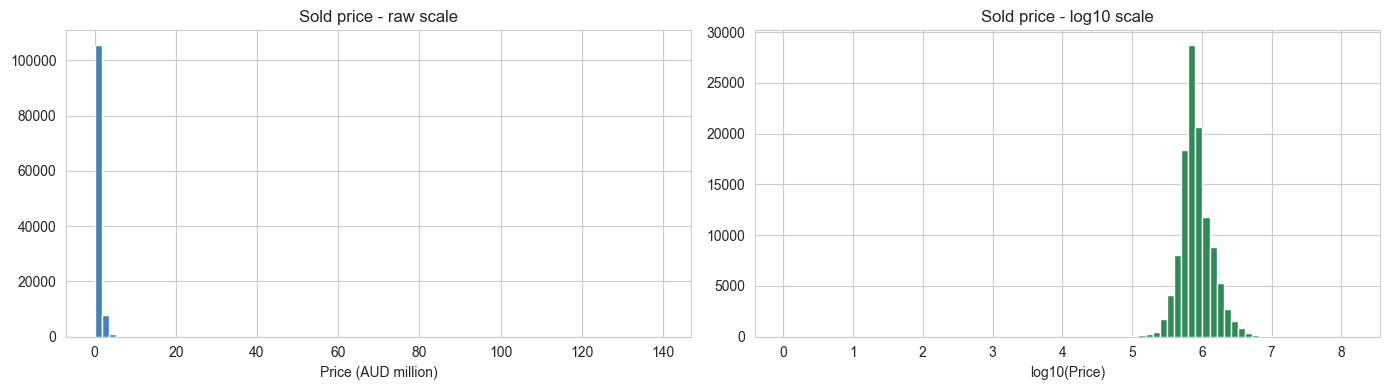

Per-Property_Type IQR bounds (k=3) on Numeric_Price (types with >=50 sales):
                         count     median        low       high
Property_Type                                                  
House                    83164   827500.0  -865000.0  2705000.0
Apartment / Unit / Flat  14235   570000.0  -315000.0  1470000.0
Townhouse                 8246   780000.0  -623001.0  2287251.0
Vacant land               6706   410000.0  -580000.0  1520000.0
Acreage / Semi-Rural      1139  1720000.0 -2058000.0  5708500.0
Rural                      379  1350000.0 -3720000.0  6815000.0
Villa                      260   715000.0  -605500.0  2044000.0
New House & Land           235   685000.0 -1057000.0  2857750.0
Block of Units              73  1250000.0 -3262000.0  5670000.0

Global Numeric_Price percentiles (Sold):
count       114624.0
mean        965566.0
std        1067423.0
min              1.0
0.1%        110000.0
1%          255000.0
5%          378000.0
95%        2100000.0
99%      

In [43]:
# Subset Sold rows that have a numeric price.
sold_priced = df_sold.dropna(subset=["Numeric_Price"]).copy()

# Two-panel histogram: raw scale (shows right tail) and log10 (shows distribution shape).
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sold_priced["Numeric_Price"] / 1e6, bins=80,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Price (AUD million)")
axes[0].set_title("Sold price - raw scale")

axes[1].hist(np.log10(sold_priced["Numeric_Price"]), bins=80,
             color="seagreen", edgecolor="white")
axes[1].set_xlabel("log10(Price)")
axes[1].set_title("Sold price - log10 scale")
plt.tight_layout(); plt.show()

# Per-Property_Type IQR bounds at k=3, only for types with at least 50 transactions
# (small types give unstable IQRs).
def iqr_bounds(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

bounds = (sold_priced.groupby("Property_Type")["Numeric_Price"]
          .agg(count="count",
               median="median",
               low =lambda x: iqr_bounds(x)[0],
               high=lambda x: iqr_bounds(x)[1])
          .query("count >= 50")
          .sort_values("count", ascending=False))

print("Per-Property_Type IQR bounds (k=3) on Numeric_Price (types with >=50 sales):")
print(bounds.round(0).to_string())

# Global price tails for context.
print("\nGlobal Numeric_Price percentiles (Sold):")
print(sold_priced["Numeric_Price"].describe(percentiles=[.001, .01, .05, .95, .99, .999]).round(0))

**Physical attribute outliers**

Beds, Baths and Car_Spaces should follow human-scale property logic:

- Residential properties typically have 1–6 bedrooms; values above 10 are almost always typos or boarding-house edge cases.

- Baths should be roughly proportional to Beds. If Baths is more than twice Beds (for non-zero Beds), the row is suspicious.

- Beds = 0 AND Baths = 0 is normal for land but anomalous for a residential type. The is_land flag built earlier handles this distinction.

I capture counts of suspicious patterns rather than dropping anything yet; cleaning is applied in one batch at the end of Section 3.

In [44]:
# Distribution and tail counts on Beds, Baths, Car_Spaces in the Sold set.
print("Beds distribution (Sold):")
print(df_sold["Beds"].describe().round(2))
print(f"  Beds > 10: {(df_sold['Beds'] > 10).sum()} rows")
print(f"  Beds = 0 AND not flagged as land: "
      f"{((df_sold['Beds'] == 0) & (df_sold['is_land'] == 0)).sum()} rows")

print("\nBaths distribution (Sold):")
print(df_sold["Baths"].describe().round(2))
print(f"  Baths > 10: {(df_sold['Baths'] > 10).sum()} rows")
print(f"  Baths > Beds*2 (with Beds > 0): "
      f"{((df_sold['Baths'] > df_sold['Beds']*2) & (df_sold['Beds'] > 0)).sum()} rows")

print("\nCar_Spaces distribution (Sold):")
print(df_sold["Car_Spaces"].describe().round(2))
print(f"  Car_Spaces > 10: {(df_sold['Car_Spaces'] > 10).sum()} rows")

# Same checks on For Sale, since the same caps will be applied to inference inputs.
print("\n--- For Sale ---")
print(f"Beds > 10:                                 {(df_forsale['Beds'] > 10).sum()}")
print(f"Beds = 0 AND not flagged as land:          "
      f"{((df_forsale['Beds'] == 0) & (df_forsale['is_land'] == 0)).sum()}")
print(f"Baths > Beds*2 (with Beds > 0):            "
      f"{((df_forsale['Baths'] > df_forsale['Beds']*2) & (df_forsale['Beds'] > 0)).sum()}")
print(f"Car_Spaces > 10:                           {(df_forsale['Car_Spaces'] > 10).sum()}")

Beds distribution (Sold):
count    124850.00
mean          3.14
std           1.29
min           0.00
25%           3.00
50%           3.00
75%           4.00
max          30.00
Name: Beds, dtype: float64
  Beds > 10: 56 rows
  Beds = 0 AND not flagged as land: 227 rows

Baths distribution (Sold):
count    124850.00
mean          1.75
std           0.85
min           0.00
25%           1.00
50%           2.00
75%           2.00
max          20.00
Name: Baths, dtype: float64
  Baths > 10: 18 rows
  Baths > Beds*2 (with Beds > 0): 4 rows

Car_Spaces distribution (Sold):
count    124850.00
mean          2.07
std          33.85
min           0.00
25%           1.00
50%           2.00
75%           2.00
max       11951.00
Name: Car_Spaces, dtype: float64
  Car_Spaces > 10: 277 rows

--- For Sale ---
Beds > 10:                                 23
Beds = 0 AND not flagged as land:          95
Baths > Beds*2 (with Beds > 0):            0
Car_Spaces > 10:                           99


**LandSize outliers**

LandSize_sqm has two distinct outlier failure modes:

- Zero land for a non-apartment, non-land property. A House or Townhouse must have land. A zero LandSize on these rows is almost always missing data masquerading as zero, and I will set it to NaN so it can be properly imputed in the ML preprocessing step.

- Extreme upper tail. Acreage and farms can legitimately have hundreds of thousands of square meters. But a "House" with 100,000 sqm is suspicious; it's likely either mislabeled (should be "Acreage" or "Rural") or a data entry error. I cap LandSize at the 99.9th percentile for non-land rows, which preserves nearly all legitimate values while neutralizing the extreme tail.

For apartment-like types (Apartment, Studio, Penthouse, Block of Units, Car Space), zero LandSize is normal and stays.

In [45]:
# LandSize percentiles to inform the cap level.
print("LandSize_sqm percentiles (Sold, all rows):")
print(df_sold["LandSize_sqm"].describe(percentiles=[.5, .9, .99, .999]).round(0))

# Zero LandSize on non-apartment, non-land property types.
APT_LIKE = {"Apartment / Unit / Flat", "Studio", "Penthouse",
            "Block of Units", "Car Space"}

bad_zero_sold = (df_sold["LandSize_sqm"] == 0) & \
                (~df_sold["Property_Type"].isin(APT_LIKE)) & \
                (df_sold["is_land"] == 0)
bad_zero_fs   = (df_forsale["LandSize_sqm"] == 0) & \
                (~df_forsale["Property_Type"].isin(APT_LIKE)) & \
                (df_forsale["is_land"] == 0)

print(f"\nLandSize=0 on non-apartment, non-land rows:")
print(f"  Sold:     {bad_zero_sold.sum():,}")
print(f"  For Sale: {bad_zero_fs.sum():,}")

# Top-tail look: largest LandSize values among non-land rows.
print("\nTop 10 largest LandSize_sqm among non-land Sold rows:")
print(df_sold[df_sold["is_land"] == 0]
      .nlargest(10, "LandSize_sqm")[["Property_Type", "Suburb", "LandSize_sqm", "Numeric_Price"]]
      .to_string(index=False))

LandSize_sqm percentiles (Sold, all rows):
count       124850.0
mean          5289.0
std         565297.0
min              0.0
50%            448.0
90%           1184.0
99%          68796.0
99.9%       449200.0
max      197433984.0
Name: LandSize_sqm, dtype: float64

LandSize=0 on non-apartment, non-land rows:
  Sold:     25,102
  For Sale: 7,776

Top 10 largest LandSize_sqm among non-land Sold rows:
       Property_Type     Suburb  LandSize_sqm  Numeric_Price
               House    GRUYERE   197433984.0      2420000.0
               House   MYRNIONG    17178100.0      1425000.0
               House  KURUNJANG     8093700.0       412500.0
               House   SORRENTO     5876000.0      1520000.0
               House     YERING     2060000.0      6500000.0
               Rural     YERING     2023400.0      8305000.0
               Rural    SUNBURY     1841300.0            NaN
               House    SUNBURY     1529700.0            NaN
Acreage / Semi-Rural CONNEWARRE     1397300.0  

**Geographic outliers**

I define a Melbourne metro envelope of approximately:

- Latitude: -38.6 to -37.4
- Longitude: 144.4 to 145.7

Properties outside this envelope are not necessarily errors. Domain.com.au lists genuinely regional properties (Geelong, Ballarat, Mornington Peninsula extensions, etc.) that are legitimately outside the inner metro box. I therefore flag rather than drop. The flag (`out_of_metro`) lets downstream geospatial visualizations focus on the metro core while still keeping regional rows in the modeling set.

In [46]:
# Count and inspect rows outside the Melbourne metro envelope.
LAT_MIN, LAT_MAX = -38.6, -37.4
LON_MIN, LON_MAX = 144.4, 145.7

geo_out_sold = df_sold[(~df_sold["Latitude"].between(LAT_MIN, LAT_MAX)) |
                       (~df_sold["Longitude"].between(LON_MIN, LON_MAX))]
geo_out_fs   = df_forsale[(~df_forsale["Latitude"].between(LAT_MIN, LAT_MAX)) |
                          (~df_forsale["Longitude"].between(LON_MIN, LON_MAX))]

print(f"Rows outside Melbourne metro envelope:")
print(f"  Sold:     {len(geo_out_sold):,}  ({len(geo_out_sold)/len(df_sold)*100:.1f}%)")
print(f"  For Sale: {len(geo_out_fs):,}  ({len(geo_out_fs)/len(df_forsale)*100:.1f}%)")

# Show a few examples to confirm these look like real regional listings rather than coordinate errors.
print("\nExamples of out-of-metro Sold rows:")
print(geo_out_sold[["Suburb", "Postcode", "Latitude", "Longitude", "Distance_to_CBD_km"]]
      .head(8).to_string(index=False))

Rows outside Melbourne metro envelope:
  Sold:     4,334  (3.5%)
  For Sale: 1,804  (4.7%)

Examples of out-of-metro Sold rows:
  Suburb  Postcode   Latitude  Longitude  Distance_to_CBD_km
KOROBEIT      3341 -37.563847  144.35050               60.64
MYRNIONG      3341 -37.562230  144.36299               59.75
MYRNIONG      3341 -37.560963  144.36370               59.76
MYRNIONG      3341 -37.565270  144.35516               60.20
MYRNIONG      3341 -37.562454  144.35805               60.12
KOROBEIT      3341 -37.565807  144.35326               60.32
MYRNIONG      3341 -37.560352  144.36017               60.06
MYRNIONG      3341 -37.577910  144.35915               59.25
